In [1]:
import numpy as np
import scipy.constants
import scipy.sparse
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import math
import geopandas as gpd
import pandas as pd
import os
import netCDF4 as nc

In [2]:
def calc_alongshore_transport_k(gravity=scipy.constants.g, n=1.0, rho_water=1050.0, gamma_b=0.78, ):
    return (
        5.3e-6
        # * 0.46
        * rho_water
        * gravity**1.5
        * (1 / (2 * n)) ** 1.2
        * (np.sqrt(gravity * gamma_b) / (2 * np.pi)) ** 0.2
    )

In [3]:
def get_angles_xr(ds):
    
    ''' Takes average latitude and longitude calculated in beahc_w_to_gps.ipynb and computes bearing using bearing formula
    \(\theta =\>\mathrm{atan2}\>(\sin \Delta \lambda \cdot \cos \phi _{2},\cos \phi _{1}\cdot \sin \phi _{2}-\sin \phi _{1}\cdot \cos \phi _{2}\cdot \cos \Delta \lambda )\)'''
    
    lat = np.radians(ds['mean_lat'])
    lon = np.radians(ds['mean_lon'])

    lat1 = lat.shift(site=1)
    lon1 = lon.shift(site=1)
    lat2 = lat.shift(site=-1)
    lon2 = lon.shift(site=-1)

    dlon = lon2 - lon1
    
    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)

    bearing = np.degrees(np.arctan2(y, x))
    bearing = (bearing + 360) % 360

    return bearing.fillna(0)

In [4]:
def calc_qs(dp, hs, tp, angles, k):

    '''Calculates Q_s using formula from Ashton, Murray 2006 B, equation (7). Negative sign is added so that positive Q_s 
    corresponds to rightward sediment movement when facing offshore (in this case, roughly south-bound).'''
    
    tp_da = tp['tp'] if isinstance(tp, xr.Dataset) else tp # just in case
    hs_da = hs['hs'] if isinstance(hs, xr.Dataset) else hs
    dp_da = dp['dp'] if isinstance(dp, xr.Dataset) else dp

    phi = dp_da - 90
    thet = ((angles + 90) % 360) - 90 # assumes no shoreline bearing angles greater than 270
    angle_term = phi - thet
    angle_term = angle_term.where(angle_term <= 90, angle_term >= -90) # mask areas where waves appear to be moving away from shore
    rad_factor = np.pi / 180
    angle_term = angle_term * rad_factor
    cos_term = np.cos(angle_term)
    sin_term = np.sin(angle_term)
    qs = -k * (tp_da ** .2) * (hs_da ** 2.4) * (cos_term ** 1.2) * sin_term # CERC formula, negative fixes the bearing assumption so that downdrift qs is positive
    # qs = -k * (hs_da ** 2) * cos_term * sin_term # breaking wave formula
    return qs, angle_term

In [6]:
# open dataset
dp0 = xr.open_dataset('dp0_NorthCarolina.nc')
dp1 = xr.open_dataset('dp1_NorthCarolina.nc')
dp2 = xr.open_dataset('dp2_NorthCarolina.nc')
dp3 = xr.open_dataset('dp3_NorthCarolina.nc')
hs0 = xr.open_dataset('phs0_NorthCarolina.nc')
hs1 = xr.open_dataset('phs1_NorthCarolina.nc')
hs2 = xr.open_dataset('phs2_NorthCarolina.nc')
hs3 = xr.open_dataset('phs3_NorthCarolina.nc')
tp0 = xr.open_dataset('ptp0_NorthCarolina.nc')
tp1 = xr.open_dataset('ptp1_NorthCarolina.nc')
tp2 = xr.open_dataset('ptp2_NorthCarolina.nc')
tp3 = xr.open_dataset('ptp3_NorthCarolina.nc')
shore = xr.open_dataset('NC_average_lat_lon.nc')

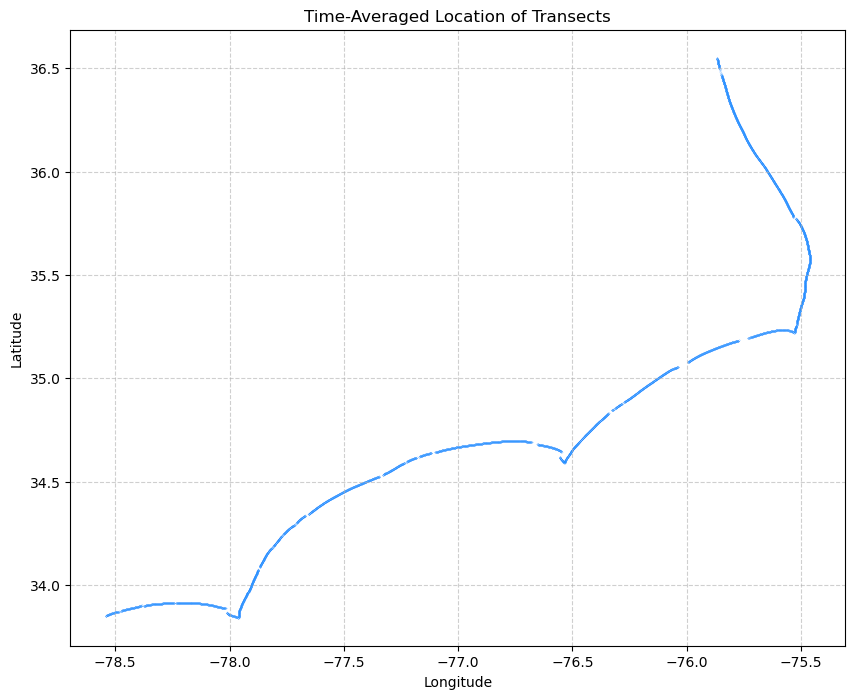

In [8]:
# plot shoreline points
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    shore['mean_lon'].values, 
    shore['mean_lat'].values, 
    s=.01, 
    c='dodgerblue', 
    alpha=0.7
)

ax.set_title('Time-Averaged Location of Transects')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.6)

In [9]:
# compute shoreline angles (bearing from north)
angles_xr = get_angles_xr(shore)

In [11]:
# extends and maps wave data to nearest transect centroid
wave_lats = dp0.lat.values
wave_lons = dp0.lon.values
transect_lats = shore['mean_lat'].values
transect_lons = shore['mean_lon'].values

def get_nearest_indices(w_lats, w_lons, t_lats, t_lons):
    indices = []
    for lat, lon in zip(t_lats, t_lons):
        dist = np.sqrt((w_lats - lat)**2 + (w_lons - lon)**2)
        indices.append(np.argmin(dist))
    return np.array(indices)

mapping_idx = get_nearest_indices(wave_lats, wave_lons, transect_lats, transect_lons)

dp0_mapped = dp0.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

dp1_mapped = dp1.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

dp2_mapped = dp2.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

dp3_mapped = dp3.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

hs0_mapped = hs0.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

hs1_mapped = hs1.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

hs2_mapped = hs2.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

hs3_mapped = hs3.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

tp0_mapped = tp0.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

tp1_mapped = tp1.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

tp2_mapped = tp2.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

tp3_mapped = tp3.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

In [ ]:
# 1. Organize datasets into dictionaries for easy access
# Note: I used the specific filenames you provided (including pdp3)
dps = {
    0: dp0_mapped
    1: dp1_mapped
    2: dp2_mapped
    3: dp3_mapped 
}

hss = {
    0: hs0_mapped
    1: hs1_mapped
    2: hs2_mapped
    3: hs3
}

tps = {
    0: tp0_mapped
    1: tp1_mapped
    2: tp2_mapped
    3: tp3_mapped
}

k = calc_alongshore_transport_k()

for i in range(4):  
    file_name = f'ncqs{i}_hourly_pertransect.nc'
    
    if os.path.exists(file_name):
        os.remove(file_name)

    dp_curr = dps[i]
    hs_curr = hss[i]
    tp_curr = tps[i]
    
    total_time_len = len(dp_curr.time)

    full_template = xr.Dataset(
        data_vars={
            "qs": (("time", "site"), np.zeros((total_time_len, len(angles_xr)), dtype='float32')),
            "angle_diff": (("time", "site"), np.zeros((total_time_len, len(angles_xr)), dtype='float32')),
            "lat": ("site", shore['mean_lat'].values),
            "lon": ("site", shore['mean_lon'].values)
        },
        coords={"time": dp_curr.time, "site": dp_curr.site}
    )

    full_template.to_netcdf(file_name) 

    with nc.Dataset(file_name, 'a') as dst:
        step = 50000
        for start_idx in range(0, total_time_len, step):
            end_idx = min(start_idx + step, total_time_len)
            print(f"File {i} | Writing indices: {start_idx} to {end_idx}...")
            
            dp_slice = dp_curr.isel(time=slice(start_idx, end_idx))
            hs_slice = hs_curr.isel(time=slice(start_idx, end_idx))
            tp_slice = tp_curr.isel(time=slice(start_idx, end_idx))
            
            qs_slice, angle_slice = calc_qs(dp_slice, hs_slice, tp_slice, angles_xr, k)
    
            dst['qs'][start_idx:end_idx, :] = qs_slice.values
            dst['angle_diff'][start_idx:end_idx, :] = angle_slice.values
    
    print(f"Successfully saved {file_name}\n")